<a href="https://colab.research.google.com/github/DataAnalyst-MiguelRodriguez/analysis-TomTom_Traffic_Index_y_OECD/blob/main/S5_ladb_mobility_economy_project_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introducción

El objetivo es **evaluar cómo la movilidad urbana se relaciona con la productividad económica en las principales ciudades latinoamericanas**.
Se trabajará con datos de TomTom Traffic Index y OECD Cities, que se limpiaran, combinaran y analizaran para identificar en qué ciudades conviene invertir en infraestructura de transporte.

##  Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de ambos datasets**.
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida



In [ ]:


# importar librerías
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt



In [ ]:

# cargar archivos
traffic = pd.read_csv('/datasets/tomtom_traffic.csv')
eco = pd.read_csv("/datasets/oecd_city_economy.csv")


In [ ]:

# mostrar las primeras 5 filas de traffic
traffic.head(5)


,Country,City,UpdateTimeUTC,JamsDelay,TrafficIndexLive,JamsLengthInKms,JamsCount,TrafficIndexWeekAgo,UpdateTimeUTCWeekAgo,TravelTimeLivePer10KmsMins,TravelTimeHistoricPer10KmsMins,MinsDelay
0,ARE,abu-dhabi,2025-01-13 04:01:30.001,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30.000,11.614767,10.265330,1.349437
1,ARE,abu-dhabi,2025-01-13 03:46:00.000,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001,11.003180,10.031544,0.971635
2,ARE,abu-dhabi,2025-01-13 02:46:30.000,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30.000,8.196278,8.196510,-0.000232
3,ARE,abu-dhabi,2025-01-13 01:46:30.001,8.2,2.0,4.1,2.0,2.0,2025-01-06 01:46:30.000,7.723808,7.899046,-0.175238
4,ARE,abu-dhabi,2025-01-13 00:01:30.000,1.1,1.0,0.2,1.0,1.0,2025-01-06 00:01:30.000,8.336363,8.604379,-0.268016


In [ ]:

# mostrar las primeras 5 filas de eco
eco.head(5)


,Year,City,Country,City GDP/capita,Unemployment %,PM2.5 (μg/m³),Population (M)
0,2023,buenos-aires,Argentina,"15.782,00",6.2%,"15,2","15,30"
1,2023,sao-paulo,Brazil,"14.475,00",9.1%,"29,50","22,50"
2,2023,rio-de-janeiro,Brazil,"13.142,00",9.8%,"19,10","13,60"
3,2023,brasilia,Brazil,"15.999,00",8.3%,"13,50","4,70"
4,2023,salvador,Brazil,"8.761,00",13.1%,"16,00","3,90"


**Tip:** Si no usas `print()` la tabla se vera mejor.


---

## Paso 2: Explorar, limpiar y preparar los datos

Antes de combinar los datasets, inspecciona su estructura, tipos de datos, columnas y valores faltantes.
Anota las columnas que necesiten limpieza y luego estandariza los nombres de columnas.

### 2.1 Explorar la estructura y tipos de datos




In [ ]:

# Examinar la estructura de traffic
traffic.info()
traffic.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 12 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   Country                         1004464 non-null  object 
 1   City                            1004464 non-null  object 
 2   UpdateTimeUTC                   1004464 non-null  object 
 3   JamsDelay                       1004464 non-null  float64
 4   TrafficIndexLive                1004464 non-null  float64
 5   JamsLengthInKms                 1004464 non-null  float64
 6   JamsCount                       1004464 non-null  float64
 7   TrafficIndexWeekAgo             1004464 non-null  float64
 8   UpdateTimeUTCWeekAgo            1004464 non-null  object 
 9   TravelTimeLivePer10KmsMins      1004464 non-null  float64
 10  TravelTimeHistoricPer10KmsMins  1004464 non-null  float64
 11  MinsDelay                       1004464 non-null  float64
dtype

Country                           0
City                              0
UpdateTimeUTC                     0
JamsDelay                         0
TrafficIndexLive                  0
JamsLengthInKms                   0
JamsCount                         0
TrafficIndexWeekAgo               0
UpdateTimeUTCWeekAgo              0
TravelTimeLivePer10KmsMins        0
TravelTimeHistoricPer10KmsMins    0
MinsDelay                         0
dtype: int64


En la estructura del DF traffic, se observa que:
- Las columnas `UpdateTimeUTC` y `UpdateTimeUTC` son de tipo "object" cuando deberian de ser "datetime"
- Sin valores ausentes


In [ ]:

# Examinar la estructura de eco
eco.info()
eco.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Year             30 non-null     int64 
 1   City             30 non-null     object
 2   Country          30 non-null     object
 3   City GDP/capita  30 non-null     object
 4   Unemployment %   30 non-null     object
 5   PM2.5 (μg/m³)    30 non-null     object
 6   Population (M)   30 non-null     object
dtypes: int64(1), object(6)
memory usage: 1.8+ KB


Year               0
City               0
Country            0
City GDP/capita    0
Unemployment %     0
PM2.5 (μg/m³)      0
Population (M)     0
dtype: int64


En la estructura del DF eco, se observa que:
- Las columnas `City GDP/capita`, `Unemployment %`, 'PM2.5 (ug/m3)', 'Population' estan en "object" cuando deben de ser "float"...
- Sin valores ausentes.


### 2.2 Renombrar columnas

**🎯Objetivo:**
Estandarizar los nombres de columnas para evitar errores y facilitar la unión de los datasets.




In [ ]:

# Estandarizar los nombres de las columnas de traffic
traffic = traffic.rename(columns={"Country": "country", "UpdateTimeUTC": "update_time_utc", "UpdateTimeUTCWeekAgo":"update_time_utc_week_ago", 'JamsDelay': 'jams_delay', 'TrafficIndexLive': 'traffic_index_live', 'JamsLengthInKms': 'jams_length_kms', 'JamsCount': 'jams_count', 'TrafficIndexWeekAgo': 'traffic_index_week_ago', 'TravelTimeLivePer10KmsMins': 'travel_time_live_per_10kms_mins', 'TravelTimeHistoricPer10KmsMins': 'travel_time_hist_per_10kms_mins', 'MinsDelay': 'mins_delay', 'City': 'city'})
# verificar cambios
traffic.columns


Index(['country', 'city', 'update_time_utc', 'jams_delay',
       'traffic_index_live', 'jams_length_kms', 'jams_count',
       'traffic_index_week_ago', 'update_time_utc_week_ago',
       'travel_time_live_per_10kms_min', 'travel_time_historic_per_10kms_mins',
       'mins_delay', 'year'],
      dtype='object')

In [ ]:

# Estandarizar los nombres de las columnas de eco
eco = eco.rename(columns={"Country": "country", "Year": "year", "City GDP/capita": "city_gdp_capita", "Unemployment %": "unemployment_pct", "Population (M)": "population_m", "City": "city", "PM2.5 (μg/m³)": "pm25"})

# verificar cambios
eco.columns


Index(['year', 'city', 'country', 'city_gdp_capita', 'unemployment_pct',
       'pm25', 'population_m', 'population'],
      dtype='object')


### 2.3 Corregir formatos numéricos y de fecha

**🎯Objetivo:**
Asegurar que las columnas de fechas y valores numéricos estén en formatos correctos para permitir análisis, cálculos y comparaciones precisas.



<details>
<summary>Haz clic para ver la pista</summary>
para eliminar símbolos, puedes reemplazarlos por un texto vacío.

In [ ]:

# Convertir las columnas de traffic a tipo fecha con pd.to_datetime()
traffic['update_time_utc'] = pd.to_datetime(traffic["update_time_utc"], errors= "coerce", utc=True)
traffic['update_time_utc_week_ago'] = pd.to_datetime(traffic["update_time_utc_week_ago"], errors= "coerce", utc=True)

# verificar el cambio
traffic.info()
traffic.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1004464 entries, 0 to 1004463
Data columns (total 13 columns):
 #   Column                               Non-Null Count    Dtype              
---  ------                               --------------    -----              
 0   country                              1004464 non-null  object             
 1   city                                 1004464 non-null  object             
 2   update_time_utc                      1004464 non-null  datetime64[ns, UTC]
 3   jams_delay                           1004464 non-null  float64            
 4   traffic_index_live                   1004464 non-null  float64            
 5   jams_length_kms                      1004464 non-null  float64            
 6   jams_count                           1004464 non-null  float64            
 7   traffic_index_week_ago               1004464 non-null  float64            
 8   update_time_utc_week_ago             1004464 non-null  datetime64[ns, UTC]
 9   tr

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_min,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [ ]:

# Limpia separadores y convierte columnas numéricas en eco
eco['city_gdp_capita'] = eco["city_gdp_capita"].astype(str).str.replace('.', '').str.replace(',', '.').astype(float)
eco['unemployment_pct'] = eco["unemployment_pct"].astype(str).str.replace("%","").str.replace(",", ".").astype(float)
eco['population_m'] = eco['population_m'].astype(str).str.replace(',', '.').astype(float)
eco['pm25'] = eco['pm25'].astype(str).str.replace(',', '.').astype(float)

# Calcula la población total en unidades absolutas (Multiplica * 1000000)
eco['population'] = eco['population_m']*1000000

# verificar el cambio
eco.info()
eco.head(3)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   year              30 non-null     int64  
 1   city              30 non-null     object 
 2   country           30 non-null     object 
 3   city_gdp_capita   30 non-null     float64
 4   unemployment_pct  30 non-null     float64
 5   pm25              30 non-null     float64
 6   population_m      30 non-null     float64
 7   population        30 non-null     float64
dtypes: float64(5), int64(1), object(2)
memory usage: 2.0+ KB


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
0,2023,buenos-aires,Argentina,157820.0,6.2,15.2,15.3,15300000.0
1,2023,sao-paulo,Brazil,144750.0,9.1,29.5,22.5,22500000.0
2,2023,rio-de-janeiro,Brazil,131420.0,9.8,19.1,13.6,13600000.0



---

## Paso 3: Extraer año y filtrar

Extraer el año permite filtrar la información y trabajar solo con el período más reciente y relevante.

### 3.1 Extraer columna año y filtrar 2024

**🎯Objetivo**
Identificar el año de cada registro y mantener solo los registros del 2024.


In [ ]:
# Extraer el año de las fechas en update_time_utc
traffic['year'] = pd.to_datetime(traffic['update_time_utc']).dt.year

# Verificar cambio
traffic.head(3)

,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_min,travel_time_historic_per_10kms_mins,mins_delay,year
0,ARE,abu-dhabi,2025-01-13 04:01:30.001000+00:00,650.7,36.0,109.1,162.0,30.0,2025-01-06 04:01:30+00:00,11.614767,10.265330,1.349437,2025
1,ARE,abu-dhabi,2025-01-13 03:46:00+00:00,540.4,30.0,101.4,136.0,27.0,2025-01-06 03:46:30.001000+00:00,11.003180,10.031544,0.971635,2025
2,ARE,abu-dhabi,2025-01-13 02:46:30+00:00,71.8,7.0,18.9,23.0,6.0,2025-01-06 02:46:30+00:00,8.196278,8.196510,-0.000232,2025


In [ ]:

# Filtra los registros del año 2024
traffic_2024 = traffic[traffic['year']== 2024].copy()
eco_2024 = eco[eco['year'] == 2024].copy()

# Revisar dataframes nuevos
display(traffic_2024.head())
display(eco_2024.head())



,country,city,update_time_utc,jams_delay,traffic_index_live,jams_length_kms,jams_count,traffic_index_week_ago,update_time_utc_week_ago,travel_time_live_per_10kms_min,travel_time_historic_per_10kms_mins,mins_delay,year
302,ARE,abu-dhabi,2024-12-31 23:01:30+00:00,12.9,5.0,2.5,5.0,2.0,2024-12-24 23:01:30.001000+00:00,8.560399,8.519634,0.040765,2024
303,ARE,abu-dhabi,2024-12-31 22:01:30+00:00,136.0,21.0,20.6,32.0,3.0,2024-12-24 22:01:30+00:00,10.355732,9.049445,1.306286,2024
304,ARE,abu-dhabi,2024-12-31 21:16:30+00:00,455.2,31.0,40.4,72.0,4.0,2024-12-24 21:01:30+00:00,11.456878,9.305174,2.151704,2024
305,ARE,abu-dhabi,2024-12-31 20:01:00.001000+00:00,399.4,27.0,38.0,75.0,6.0,2024-12-24 20:01:30.001000+00:00,11.670062,9.952811,1.717252,2024
306,ARE,abu-dhabi,2024-12-31 19:46:00+00:00,366.4,28.0,39.8,82.0,9.0,2024-12-24 19:01:00+00:00,11.686322,10.008469,1.677853,2024


,year,city,country,city_gdp_capita,unemployment_pct,pm25,population_m,population
15,2024,buenos-aires,Argentina,181170.0,7.2,14.5,15.4,15400000.0
16,2024,sao-paulo,Brazil,147030.0,8.5,28.0,22.6,22600000.0
17,2024,rio-de-janeiro,Brazil,133490.0,9.2,18.4,13.7,13700000.0
18,2024,brasilia,Brazil,162510.0,7.8,12.8,4.8,4800000.0
19,2024,salvador,Brazil,88990.0,12.4,15.2,3.9,3900000.0



---

## Paso 4: Analizar y resumir datos de movilidad

Como el dataset de tráfico contiene **múltiples registros por ciudad**. En esta parte, calcularás los promedios anuales por ciudad para simplificar el análisis y obtener una visión más clara de las tendencias generales.

### 4.1 Calcular promedios de tráfico por ciudad

**🎯Objetivo:**
Obtener una vista consolidada del tráfico promedio por ciudad y año, para analizar patrones generales sin depender de datos diarios.



<details>
<summary>Haz clic para ver la pista</summary>
Usa ".agg()" para aplicar funciones de promedio. Al final, reinicia el índice para mantener las columnas de la agrupación como variables (no índices).

In [ ]:

# Calcular los  promedios de trafico por ciudad, país y año

traffic_city_year_2024 =  traffic_2024.groupby(['city', 'country', 'year'])['jams_delay', 'traffic_index_live', 'jams_length_kms', 'jams_count', 'mins_delay', 'travel_time_live_per_10kms_min', 'travel_time_historic_per_10kms_mins'].mean().reset_index()


# Mostrar resultado
traffic_city_year_2024.head()


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_min,travel_time_historic_per_10kms_mins
0,a-coruna,ESP,2024,17.935187,15.259774,2.198002,4.934405,0.774172,16.267977,15.493804
1,aachen,DEU,2024,26.732141,20.960314,3.892586,6.601832,0.792968,13.397861,12.604894
2,aarhus,DNK,2024,21.200616,16.575891,2.736736,6.109987,0.495276,15.219292,14.724016
3,abu-dhabi,ARE,2024,171.157315,13.902028,24.507380,47.268019,0.139764,9.829092,9.689328
4,adana,TUR,2024,83.864761,22.541040,11.827331,23.754620,1.129749,15.879694,14.749945


- ¿Cuál tiene el mayor tiempo promedio de tráfico?
- ¿Será una ciudad de **Europa**, de **Latinoamérica** o de **otra región** del mundo?

`traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)`


In [ ]:
traffic_city_year_2024.sort_values(["jams_delay"], ascending=False)

,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_min,travel_time_historic_per_10kms_mins
221,mexico-city,MEX,2024,2833.057892,34.218190,389.239265,594.969392,1.855542,21.809092,19.953550
352,tokyo,JPN,2024,2152.574357,36.805059,373.069734,518.809420,0.698152,22.443778,21.745626
246,new-york,USA,2024,2133.400000,28.210388,398.227892,544.474902,1.396351,18.505043,17.108691
200,london,GBR,2024,2050.703662,29.230166,287.632868,471.795554,1.325160,17.714139,16.388979
211,manila,PHL,2024,1741.493381,66.129402,246.858082,341.881205,2.469894,27.134629,24.664734
...,...,...,...,...,...,...,...,...,...,...
111,dunedin,NZL,2024,4.651175,15.430809,0.712315,1.591384,0.633294,16.226009,15.592715
363,uppsala,SWE,2024,4.194486,13.939168,0.656368,1.349672,0.501802,15.746717,15.244916
123,fujairah,ARE,2024,4.025959,10.907719,0.731910,1.373006,0.194951,11.662590,11.467639
12,almere,NLD,2024,3.633523,6.290478,0.506362,1.064063,-0.017544,9.467150,9.484694


La ciudad con el mayor tiempo promedio de tráfico es CDMX


---

## Paso 5: Unir movilidad y economía

Combinar datasets te permite analizar cómo se relacionan los indicadores económicos con los de movilidad.

### 5.1 Unir tráfico (tabla principal) con indicadores económicos

**🎯Objetivo:**
Combinar la información de tráfico y economía en un solo DataFrame para analizar cómo las condiciones económicas se relacionan con la movilidad urbana.



<details>
<summary>Haz clic para ver la pista</summary>
Aplica una unión de tipo "inner" para mantener las ciudades y años presentes en ambos datasets.

In [ ]:

# Seleccionar columnas clave de tráfico y economía
left_cols = ['city','country','year','jams_delay','traffic_index_live',
             'jams_length_kms','jams_count','mins_delay',
             'travel_time_live_per_10kms_min','travel_time_historic_per_10kms_mins']

right_cols = ['city','year','city_gdp_capita','unemployment_pct','pm25','population']

# Usar .copy() para crear los dos nuevos datasets reducidos
traffic_2024_small = traffic_city_year_2024[left_cols].copy()
eco_2024_small = eco_2024[right_cols].copy()

# Unir datasets
merged = pd.merge(traffic_2024_small, eco_2024_small, on= ['city', 'year'], how= 'inner')

# Mostrar las primeras 5 filas
merged.head(5)


,city,country,year,jams_delay,traffic_index_live,jams_length_kms,jams_count,mins_delay,travel_time_live_per_10kms_min,travel_time_historic_per_10kms_mins,city_gdp_capita,unemployment_pct,pm25,population
0,belo-horizonte,BRA,2024,263.047879,19.428946,44.038129,68.805422,0.487228,18.304538,17.817311,111240.0,9.5,16.8,6100000.0
1,bogota,COL,2024,1141.552364,37.614273,140.893564,230.566550,1.699628,24.992185,23.292557,114420.0,10.0,17.6,11300000.0
2,brasilia,BRA,2024,101.576326,11.258220,18.337133,27.280140,0.193442,13.338658,13.145216,162510.0,7.8,12.8,4800000.0
3,buenos-aires,ARG,2024,571.089593,17.756012,100.287844,137.359860,0.416566,17.907916,17.491349,181170.0,7.2,14.5,15400000.0
4,curitiba,BRA,2024,183.469274,14.954545,30.050044,46.898164,0.139965,17.258700,17.118736,123810.0,8.2,13.5,3700000.0



---

## Paso 6: Visualización y análisis de relaciones

Ahora que tienes un dataset limpio y unificado, es momento de **visualizar patrones**.
Los gráficos te ayudarán a entender cómo se relacionan las variables económicas con las de movilidad urbana.

### 6.1 Visualizar relaciones entre economía y tráfico

**🎯Objetivo:**
Analizar visualmente la distribución y la relación entre indicadores de tráfico y economía en 2024, para identificar posibles patrones o tendencias generales entre ambas variables.


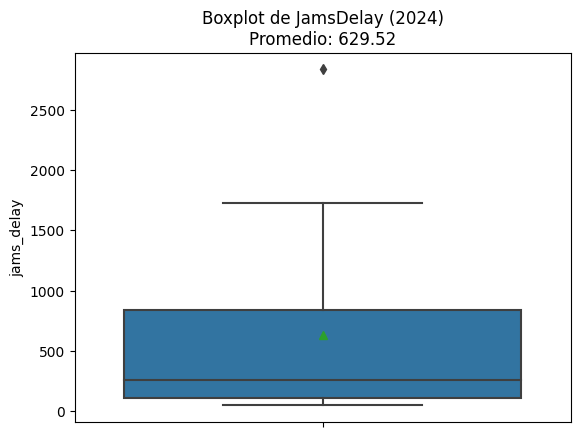

In [ ]:


# Crear boxplot para observar el comportamiento de los minutos de congestion JamsDelay
# crea tu gráfico

sb.boxplot(data= merged, y= 'jams_delay', showmeans=True)

# obtener promedio para mostrarlo en título
mean_value = merged['jams_delay'].mean()
plt.title(f'Boxplot de JamsDelay (2024)\nPromedio: {mean_value:.2f}')
plt.show()




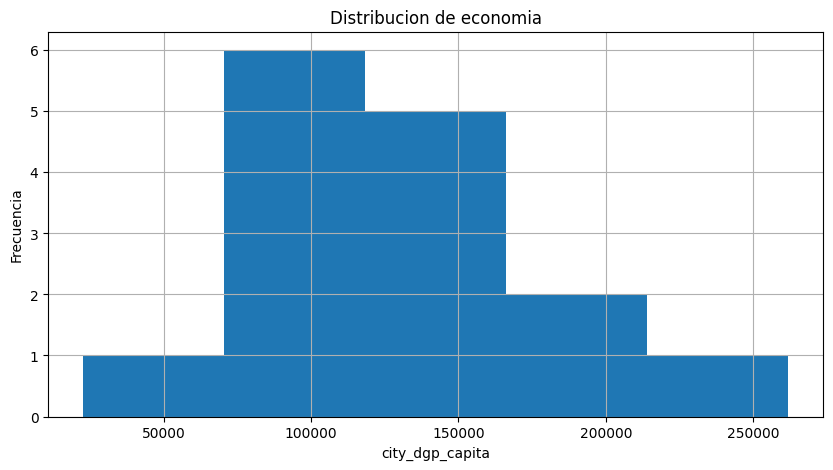

In [ ]:

# Crear histograma para ver la distribución de la economía (city_gdp_capita)
merged['city_gdp_capita'].hist(bins=5, figsize=(10, 5))
plt.title('Distribucion de economia')
plt.xlabel('city_dgp_capita')
plt.ylabel('Frecuencia')
plt.show()



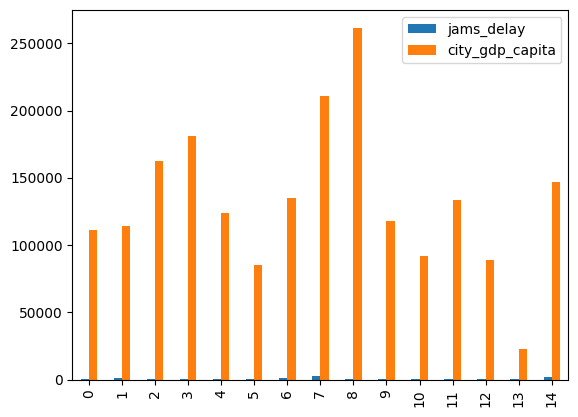

In [ ]:

# Gráfico de barras para comparar jams_delay y city_gdp_capita por ciudad

merged.plot(kind='bar', y=['jams_delay', 'city_gdp_capita'])
plt.xticks(rotation=90)
plt.show()


**Tip:** Antes del `plt.show()` agrega el código `plt.xticks(rotation=90)` para rotar las etiquetas del eje X en 90 grados.

* ¿Las ciudades con mayor PIB per cápita también presentan más congestión?

* ¿O sucede lo contrario, o no existe una relación clara?

En realidad no alcanzo a ver relacion alguna entre el PIB per capita y la congestion.
Por lo que concluyo que no existe relacion alguna.


---

## Paso 7: Documentar resultados

### 7.1 Guardar dataset final

**🎯Objetivo:**
Generar un CSV limpio, reproducible y con columnas relevantes para análisis posterior.



In [ ]:
# Exporta el dataset final como CSV
merged.to_csv("ladb_mobility_economy_2024_clean.csv", index=False)

In [ ]:
🧾 Resumen ejecutivo (plantilla)

Contexto & objetivo:

¿Qué relación existe entre la movilidad urbana (congestión, tiempos de viaje) y la productividad económica (PIB per cápita)?
No existe relacion alguna.
Al limpiar los datasets para hacer el estudio utilizamos las variables de congestionamiento vial (jams_delay) el cual nos ayudo a saber las ciudades con mayor congestionamiento; y la economia actual de la ciudad (city_gdp_capita) la cual nos ayudo a ver el desarrollo economico con el que cuenta la ciudad.
Cobertura de datos:

Este analisis fue llevado acabo para el año 2024, donde se analizaron 15 ciudades distintas en 7 paises.
Metodología (alto nivel):

Al cargar los datasets se hizo una revision para enteneder su contenido. Una vez entendido el contenido de los datasets pasamos a inpeccionar su esctructura, revisar los tipos de datos por columna, la cantidad de columnas y ver si contenian valores faltantes. Pasamos a estandarizar los nombres de las columnas, esto para evitar errores y facilitar la union de los datasets. A continuacion, corregimos los formatos de las columnas que se necesitaban corregir, en este caso object por datetime y float y cambiar algunas comas por puntos y puntos por comas y al final tuvimos que extraer el año de la columna update_time_utc debido al formato datetime.
Explica la agregación por ciudad–año y el uso de una unión INNER para integrar tráfico y economía.
Para poder hacer la union de los dos datasets, del data set TOMTOM_TRAFFIC se tuvo que hacer la extraccion del año de "update_time_utc" con .dt.year y colocar el año en una columna nueva llamada "year", asi como se estandarizaron la columna "country" de TOMTOM_TRAFFIC y de OECD_CITY_ECONOMY esto para poder crear una union del tipo INNER.
Como el dataset de trafico contenia multiples registros por ciudad, se calcularon los promedios anuales por ciudad, esto para simplificar el analisis y tener una vision mas clara de las tendencias generales.
Hallazgos iniciales:

Los indices de TOMTOM_TRAFFIC nos ayudan a comprender las congestiones viales que existen en la actualidad, como las metropoli de los paises tienden a ser las mas congestionadas y hasta nos puede ayudar a comprender el tiempo que las personas pierden arriba de sus vehiculos. Por otra parte OECD_CITY_ECONOMY nos da una idea como el crecimiento economico de una ciudad atrae a las personas, es claro como los indices de este datasets muestran que a mayor ecnomomia, mayor poblacion y por lo tanto mayor indice de desempleo.
Destaca anomalías u outliers que podrían requerir revisión adicional o un análisis más profundo.
Es imnportante ponerle atencion a los indices de TRAFFIC, ya que contienen una desviacion bastante alta, lo cual nos indica que en vez de usar una media, seria mas adecuado usar una mediana. Es importante analisar mas profundamente.
Recomendaciones
Es importante analizar Santiado de Chile, que es de las ciudades que presenta una de las mas altas congestiones y de la mas baja productvidad economica. Por otro lado, Montevideo, Uruguay, seria el pais con mejor movilidad eficiente y economia fuerte por lo que sria una buena propuesta de inversion.

¿Qué ciudad : Bogotá, Lima o Buenos Aires o alguna otra en particular, muestra la mayor correlación significativa entre altos niveles de congestión vehicular y bajos indicadores de productividad económica, sugiriendo ser una ciudad prioritaria para inversión en infraestructura de transporte?
Bogota, Colombia.
